In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "0" 
os.environ["GRB_LICENSE_FILE"] = "/usr0/home/naveenr/gurobi.lic" 
os.environ['MKL_THREADING_LAYER'] = "GNU"
import torch 

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
from concept_abstraction.training import *
from concept_abstraction.selection import *
from concept_abstraction.concept_bank import *
from concept_abstraction.env_utils import *
from concept_abstraction.environments import *
from concept_abstraction.utils import *
from concept_abstraction.environments import ConceptEnv
import sys 
import argparse
import secrets
import numpy as np 
import random 
import os
from stable_baselines3 import PPO
import pickle
import resource
import time 

In [4]:
is_jupyter = 'ipykernel' in sys.modules
is_main = __name__ == "__main__"

In [22]:
if is_main:
    seed = 42
    environment_string = "cart_pole"
    gold_timesteps = 4_000_000
    training_timesteps = 1_000_000 
    num_concepts_selected = 3
    out_folder = "basic"
    method = "lp" 


In [23]:
for seed in [44]:
    concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))
    ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
    model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
    if os.path.exists(model_name):
        groundtruth_model = PPO.load(model_name)

    model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,seed,"q_value","human_selected_binary")
    if os.path.exists(model_name):
        q_estimates = pickle.load(open(model_name,"rb"))
    # subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates,"human_selected_binary")
    # print(seed,idx)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [24]:
q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,total_timesteps=200_000)
subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates,"human_selected_binary")
idx

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated



Starting stable training for sparse rewards...
Total of 200000 steps
Step 0/200000, Loss mean: 0.0000
Episode 25, Avg Reward: 156.80, Loss (mean/std/max): 0.29/0.30/1.03, Epsilon: 0.095
Step 5000/200000, Loss mean: 0.1987
Episode 50, Avg Reward: 145.88, Loss (mean/std/max): 0.03/0.01/0.06, Epsilon: 0.090
Step 10000/200000, Loss mean: 0.0284
Episode 75, Avg Reward: 97.20, Loss (mean/std/max): 0.03/0.01/0.06, Epsilon: 0.088
Episode 100, Avg Reward: 158.64, Loss (mean/std/max): 0.03/0.01/0.04, Epsilon: 0.083
Step 15000/200000, Loss mean: 0.0273
Episode 125, Avg Reward: 170.32, Loss (mean/std/max): 0.02/0.01/0.04, Epsilon: 0.079
Step 20000/200000, Loss mean: 0.0230
Updated target network at step 500, Avg recent loss: 0.0227
Episode 150, Avg Reward: 117.08, Loss (mean/std/max): 0.21/0.32/1.08, Epsilon: 0.076
Episode 175, Avg Reward: 116.28, Loss (mean/std/max): 0.06/0.11/0.53, Epsilon: 0.073
Step 25000/200000, Loss mean: 0.0425
Episode 200, Avg Reward: 136.12, Loss (mean/std/max): 0.02/0.01

[4, 5, 10]

In [25]:
for seed in [43]:
    concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))
    ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
    model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
    if os.path.exists(model_name):
        groundtruth_model = PPO.load(model_name)

    model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,seed,"q_value","human_selected_binary")
    if os.path.exists(model_name):
        q_estimates = pickle.load(open(model_name,"rb"))
    # subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates,"human_selected_binary")
    # print(seed,idx)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [26]:
q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,total_timesteps=200_000)
subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates,"human_selected_binary")
idx

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated



Starting stable training for sparse rewards...
Total of 200000 steps
Step 0/200000, Loss mean: 0.0000
Episode 25, Avg Reward: 105.12, Loss (mean/std/max): 0.42/0.41/1.38, Epsilon: 0.095
Step 5000/200000, Loss mean: 0.1672
Episode 50, Avg Reward: 176.24, Loss (mean/std/max): 0.02/0.01/0.04, Epsilon: 0.091
Step 10000/200000, Loss mean: 0.0200
Episode 75, Avg Reward: 153.32, Loss (mean/std/max): 0.02/0.01/0.05, Epsilon: 0.086
Step 15000/200000, Loss mean: 0.0204
Episode 100, Avg Reward: 155.64, Loss (mean/std/max): 0.02/0.01/0.05, Epsilon: 0.083
Episode 125, Avg Reward: 169.76, Loss (mean/std/max): 0.02/0.01/0.04, Epsilon: 0.078
Step 20000/200000, Loss mean: 0.0167
Updated target network at step 500, Avg recent loss: 0.0166
Episode 150, Avg Reward: 156.44, Loss (mean/std/max): 0.18/0.29/1.04, Epsilon: 0.075
Step 25000/200000, Loss mean: 0.0358
Episode 175, Avg Reward: 115.44, Loss (mean/std/max): 0.02/0.02/0.09, Epsilon: 0.072
Step 30000/200000, Loss mean: 0.0190
Episode 200, Avg Reward: 

[1, 5, 11]

In [20]:
two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=250_000,custom_name="{}_perfect_lp_{}".format(environment_string,seed))    


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


KeyboardInterrupt: 

In [11]:

if is_main:
    concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))
    ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
    model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
    if os.path.exists(model_name):
        groundtruth_model = PPO.load(model_name)
    else:
        if "cyclic" in environment_string or "tree" in environment_string or "glucose" in environment_string:
            policy = "MlpPolicy"
        else:
            policy = "CnnPolicy"

        if policy == "MlpPolicy":
            groundtruth_model = train_ppo_model(ground_truth_env,environment_string+"_raw",total_timesteps=gold_timesteps,policy=policy)
        else:
            groundtruth_model = train_ppo_model(ground_truth_env,environment_string,total_timesteps=gold_timesteps,policy=policy)
        
        groundtruth_model.save(model_name)
    

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [12]:
model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,seed,"q_value","human_selected_binary")
if os.path.exists(model_name):
    q_estimates = pickle.load(open(model_name,"rb"))

In [13]:
num_concepts_selected = 57

In [25]:
discretized_X = np.array([i[0] for i in q_estimates])
unique_actions = list(set([int(i[1]) for i in q_estimates]))
actions = np.array([i[1] for i in q_estimates])
q_values = np.array([i[2] for i in q_estimates])

final_vals = []
seen = set()
for a in unique_actions:
    relevant_idx = np.where(actions == a)[0]
    if len(relevant_idx) <= 500:
        relevant_low = relevant_high = relevant_idx
    else:
        relevant_low = np.argsort(np.abs(q_values))[:500]
        relevant_high = np.argsort(np.abs(q_values))[-500:]
    for low_idx in relevant_low:
        for high_idx in relevant_high:
            diff = abs(q_values[low_idx] - q_values[high_idx])
            # tuple of differing concept indices
            diffs = tuple(i for i, (l, h) in enumerate(zip(discretized_X[low_idx], discretized_X[high_idx])) if l != h)
            tup = (diff, diffs)
            if diffs not in seen and diffs != ():
                seen.add(diffs)
                final_vals.append(tup)

# if len(final_vals) > 50_000:
#     final_vals = random.sample(final_vals,50_000)

final_vals = sorted(final_vals,reverse=True)

In [24]:
final_vals[0]

(1.3655036501586437,
 (3,
  4,
  6,
  15,
  16,
  18,
  27,
  28,
  30,
  39,
  40,
  42,
  51,
  52,
  54,
  58,
  61,
  63,
  64,
  66,
  70,
  73,
  75,
  76,
  78,
  82,
  85,
  87,
  88,
  90,
  94,
  97,
  99,
  100,
  102,
  104,
  105,
  106,
  109,
  110,
  111,
  112,
  114,
  115,
  116,
  117,
  118,
  120,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  147,
  148,
  150,
  151,
  159,
  160,
  162,
  163,
  171,
  172,
  174))

In [18]:
len(final_vals)

50000

In [27]:
idx, _ = max_prefix_gurobi(final_vals,num_concepts_selected)

In [29]:
idx

[15, 61, 86]

In [45]:
model_name

'../../results/q_estimates/env=pong_training=15000000_seed=43_selection=q_value_source=human_selected_binary.pkl'

In [46]:
q_estimates = pickle.load(open(model_name,"rb"))

In [47]:
subset_concept, idx = lp_based_selection(ground_truth_env,concept_list,num_concepts_selected,"q_value",q_estimates,"human_selected_binary")

In [48]:
idx 

[4,
 6,
 39,
 50,
 61,
 65,
 73,
 74,
 84,
 86,
 96,
 99,
 101,
 106,
 110,
 119,
 122,
 123,
 124,
 131,
 132,
 141,
 150,
 151,
 153,
 163,
 175,
 222]

In [30]:
q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list)

Starting stable training for sparse rewards...
Total of 100000 steps
Step 0/100000, Loss mean: 0.0000
Step 5000/100000, Loss mean: 0.8599
Step 10000/100000, Loss mean: 0.9120
Step 15000/100000, Loss mean: 0.8716
Step 20000/100000, Loss mean: 0.9107
Updated target network at step 500, Avg recent loss: 0.9274
Step 25000/100000, Loss mean: 0.0478
Step 30000/100000, Loss mean: 0.0487
Step 35000/100000, Loss mean: 0.0439
Step 40000/100000, Loss mean: 0.0436
Updated target network at step 1000, Avg recent loss: 0.0434
Step 45000/100000, Loss mean: 0.0231
Step 50000/100000, Loss mean: 0.0217
Step 55000/100000, Loss mean: 0.0204
Step 60000/100000, Loss mean: 0.0207
Updated target network at step 1500, Avg recent loss: 0.0205
Step 65000/100000, Loss mean: 0.0167
Step 70000/100000, Loss mean: 0.0146
Step 75000/100000, Loss mean: 0.0131
Step 80000/100000, Loss mean: 0.0131
Updated target network at step 2000, Avg recent loss: 0.0131
Step 85000/100000, Loss mean: 0.0125
Step 90000/100000, Loss mea

In [38]:
len(idx), num_concepts_selected, len(q_estimates)

(29, 57, 19163)

In [44]:
model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,43,"q_value","human_selected_binary")
pickle.dump(q_estimates,open(model_name,"wb"))

In [50]:
len(idx)

28

In [32]:
two_stage_env, two_stage_gym_env = get_environment(environment_string,subset_concept,seed,processed_concepts=processed_concepts,concept_idx=idx)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_perfect_lp_{}".format(environment_string,seed))    
lp_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,model,seed)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
wandb: Currently logged in as: naveenr (naveenr-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


KeyboardInterrupt: 

In [39]:
ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [53]:
environment_string = "cart_pole"
seed = 43
ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
num_concepts_selected = len(concept_list)


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [57]:
seed = 42
environment_string = "pong"
gold_timesteps = 15_000_000
ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed)   
model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
groundtruth_model = PPO.load(model_name)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

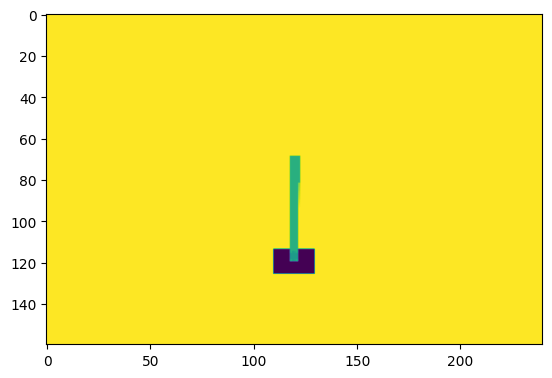

In [14]:
import matplotlib.pyplot as plt 
plt.imshow(ground_truth_gym_env.reset()[0][0][0])

In [24]:
if is_main:
    concept_list, processed_concepts = get_concepts(environment_string,"human_selected_binary",seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))
    ground_truth_env, ground_truth_gym_env = get_environment(environment_string, None, seed,processed_concepts=processed_concepts)   
    model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
    if os.path.exists(model_name):
        groundtruth_model = PPO.load(model_name)
    two_stage_env, two_stage_gym_env = get_environment(environment_string,concept_list,seed,concept_idx=list(range(len(concept_list))),processed_concepts=processed_concepts)
    two_stage_env.reset().shape

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [25]:
groundtruth_model.observation_space

Box(0, 255, (4, 84, 84), uint8)

In [26]:
model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,seed,"q_value","human_selected_binary")
if os.path.exists(model_name):
    q_estimates = pickle.load(open(model_name,"rb"))

In [27]:
model_name = "../../results/models/concept_predictor_env={}_training={}_seed={}.pth".format(environment_string,100,seed)

height = width = 84

if environment_string == "mini_grid":
    num_frames = 1
else:
    num_frames = 4

if environment_string == "cart_pole":
    height = 160
    width = 240

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if os.path.exists(model_name):
    concept_predictor = ConceptPredictorCNN(len(concept_list), num_frames=num_frames,height=height,width=width).to(device)
    concept_predictor.load_state_dict(torch.load(model_name, weights_only=True))
    concept_predictor.eval()

In [28]:
a,b = ground_truth_gym_env.reset()

In [29]:
np.mean(torch.sigmoid(concept_predictor(torch.tensor(a).float().cuda())[0]).detach().cpu().numpy() == np.array([c(b[0]['observation']) for c in concept_list]))

0.8333333333333334

In [61]:
concept_predictor, acc_list = train_concept_predictor(ground_truth_gym_env,groundtruth_model,concept_list,list(range(len(concept_list))),environment_string,epochs=25,max_episode_length=10_000)
acc_list 

ValueError: Error: Unexpected observation shape (4, 4, 84, 84) for Box environment, please use (1, 84, 84) or (n_env, 1, 84, 84) for the observation shape.

In [44]:
acc_list = evaluate_concept_predictor(concept_predictor,ground_truth_gym_env,groundtruth_model,concept_list,NUM_EPISODES=1)
acc_list.tolist()

Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration 8000/10000
Iteration 9000/10000
Iteration 10000/10000

✅ Collection complete!
X shape: (11678, 1, 84, 84), dtype: uint8, size: 78.6 MB
Y shape: (11678, 12), dtype: float32
Y contains 12 features per sample
Evaluation data - X shape: (11678, 1, 84, 84), Y shape: (11678, 44)
Evaluating concept predictor...

📊 Evaluation Results:
Overall F1 Score: 0.9429

Per-concept accuracy:
  ✅ Concept 0: 0.902
  ✅ Concept 1: 1.000
  ✅ Concept 2: 0.902
  ✅ Concept 3: 1.000
  ✅ Concept 4: 1.000
  ✅ Concept 5: 0.966
  ✅ Concept 6: 0.968
  ✅ Concept 7: 0.934
  ✅ Concept 8: 1.000
  ✅ Concept 9: 1.000
  ✅ Concept 10: 0.926
  ✅ Concept 11: 0.976
  ✅ Concept 12: 0.977
  ✅ Concept 13: 1.000
  ✅ Concept 14: 0.902
  ✅ Concept 15: 1.000
  ✅ Concept 16: 1.000
  ✅ Concept 17: 1.000
  ✅ Concept 18: 1.000
  ✅ Concept 19: 0.968
  ✅ Concept 20: 0.965
  ✅ Concept 21

[0.901695495804076,
 1.0,
 0.901695495804076,
 1.0,
 1.0,
 0.9662613461209111,
 0.9680595992464464,
 0.9343209453673574,
 1.0,
 1.0,
 0.9261003596506251,
 0.9759376605583148,
 0.9769652337729063,
 1.0,
 0.901695495804076,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9678883370440143,
 0.9651481418051037,
 0.968659016954958,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9521322144202774,
 0.9521322144202774,
 1.0,
 1.0,
 1.0,
 0.901695495804076,
 0.901695495804076,
 1.0,
 1.0,
 0.9677170748415824,
 0.9677170748415824,
 1.0,
 1.0,
 0.9328652166466861,
 0.9328652166466861]

In [25]:
two_stage_env, two_stage_gym_env = get_environment(environment_string,concept_list,seed,concept_idx=list(range(len(concept_list))),processed_concepts=processed_concepts)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_imperfect_concepts".format(environment_string))

approx_kl,██▆▄▄▃▃▃▃▃▁▃▂▂▄▃▂▃▂▂▃▃▅▄▄▃▂▃▃▅▁▅▁▃▁▂▂▂▂▂
clip_fraction,█▅▃▂▂▂▂▂▂▂▄▂▂▁▁▁▁▃▃▄▅▅▂▇▅▃▂▃▂▃▄▄▃▂▂▁▂▃▃▃
ema_norm_reward,▁▁▁▁▁▂▁▁▂▂▃▅▅▇█▇██▇▆▆▄▅▄▅▅▅▅▆▅▅▅▅▆▆▆▆▆▆▇
entropy_loss,▁▄▄▄▅▇▇▇▇▇██▇▆▆▆▇▇▇▇▇▇▇▇▆▇▇▇▇▇▇██████▇▇▇
episode_length_mean,▁▁▁▁▁▁▂▃▃▃▄█▅▆▇██▁█▅▄▇▃▃▃▄▃▄▄▄▅▃▄▄▄▄▆▅▄▄
episode_reward_max,▁▁▁▁▁▂▁▂▂▂▂▂▁▃▂▃▄▅█▇▇▆▇▄▇▄▆▅▇▃▃▃▃▃▅▄█▄▄▃
episode_reward_mean,▁▁▁▁▁▁▁▂▂▁▃▃▄▆▂▄▃█▅▆▄▇▅▅▄▄▃▅▅▃▅█▅▅▅▄▆█▅▆
episode_reward_min,▁▁▁▁▁▁▁▁▁▂▁▄█▂▄▇▃▇█▄█▇▆█▅▅▄▄▄▃▃▃▄▃▇▄▄▅▃▅
episodes_completed,▁▁▁▁▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
explained_variance,▅▅▇▇▇▄▆▃▃▂▇▇▆▆▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁▂▂██▆▄▄▃▃▁▃
+1,...


In [26]:
two_stage_env, two_stage_gym_env = get_environment(environment_string,concept_list,seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=list(range(len(concept_list))),processed_concepts=processed_concepts)
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_imperfect_concepts".format(environment_string))

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,█▁▂▂▂▁▄▄▃▂▄▃▄▃▃▃▄▂▃▃▃▃▂▂▂▂▂▂▃▄▁▃▃▆▆▁▂▁▃▂
clip_fraction,▁▁▂▃▁▂▇▃▃▃▃▄▄▂▃▃▆▆▅▅▃▅▅██▃▆▁▂▅▁▄▅▆▆▁▁▁▁▂
ema_norm_reward,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▃▄▆▇▆▆▆▇▆▆▆▇▆▇▇▇███▇
entropy_loss,▁▄▄▄▅▅▆▆▆▆▆▇██▇▇▇▇███▇█████▇▇▇▇▇▇▇▇▇██▇█
episode_length_mean,▁▁▁▁▁▁▂▂▂▃▃▃▂▃▃▂▃▂▄▅▃▆█▅▅▅██▃██████▄████
episode_reward_max,▁▁▁▁▁▂▁▂▃▂▃▂▃▃▂▃▃▃▃▃▆▃█▃▆█▄▄████▄███████
episode_reward_mean,▁▁▁▂▁▂▃▂▃▂▃▃▂▂▅▃▄▃▅▆█▃▃▃▇▅███▄▃▇████▅█▆█
episode_reward_min,▁▁▁▂▁▁▁▂▂▃▄▂▄▇▃▄▃▆▇███▆▃▄██▃▇█▃▄█████▆█▃
episodes_completed,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇████
explained_variance,▇▇▅▅▇▇▇▇▇▇▇█▇▇▇▇▇▇█▅▅▅███▇▇█▇▇▇▅▄▄▇▇▁▇▇█
+1,...


In [199]:
two_stage_env, two_stage_gym_env = get_environment(environment_string,concept_list,seed,processed_concepts=processed_concepts,concept_idx=list(range(len(concept_list))))
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_perfect_concepts".format(environment_string))    


approx_kl,▁▁▂▂▄▂▂▁▂▂▂▄▄▄▃▃▃▄▄▄▄▂▄▇▇▃▃▄▄▄▄▄▅▅█▆▆▆██
clip_fraction,▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▁▂▂▂▄▂███▄▃▅▅▅▃▃▅▅▅▅█
ema_norm_reward,▂▁▁▁▁▁▁▁▁▂▁▂▂▂▂▃▂▂▄▃▃▄▄▅▅▆▆▅▅▇▆▆▇▇▇▇████
entropy_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇███
episode_length_mean,███████▃████▅█▅█▆▂███▃▂▂▃▂▃▅▃▃▃▂▂▅▂▂▂▂▂▁
episode_reward_max,▁▁▁▃▁▁▁▄▁▁▁█▁▃▁▅▅▁▁▆▁▄▄▁▅▅▇▁▃▄█████████▅
episode_reward_mean,▁▁▅▁▁▃▁▃▁▁▁▁▁▁▁▅▅▆▁▄▇▅▃▁▆▂▆▇█▇▇██▇██▇▇█▇
episode_reward_min,▆▁▃▁▁▁▁▁▆▃▁▁▁▄▁▁▇▅▅▁▁▁▁▅▇█▇▆▅██▇▇█▆▇█▇██
episodes_completed,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇████
explained_variance,▁▁▅▅▅▄▅▅▅▅▅▅▅▅▄▆▇▆▇▇▇▇▇▇▇▇▇▇▇███████████
+1,...


In [198]:
train_ppo_model(vec_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_perfect_random".format(environment_string))        

approx_kl,▂▁▁▁▃▃▃▃▁▁▄▃▃▃▃▄▄▄▄█▅▃▃▅▅▅▅▅▆▅▄▄▅▅▅▆▆▆▆▆
clip_fraction,▁▁▁▁▁▁▁▁▁▁▁▃▁▁▃▃▄▄▄▄▁▁▂▂▃▃▃▄▄▄▃▄▃▅▅▅▅██▅
ema_norm_reward,▁▁▁▁▁▁▁▂▁▂▂▃▂▂▂▃▂▃▃▃▃▄▃▅▄▆▅▅▆▅▇▇▇▇▇█████
entropy_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▂▃▃▄▄▄▄▄▅▅▆▆▇▇▇▇██
episode_length_mean,████████▇██▄█▃▄▇▅▂▁▆▅▁▁▂▂█▃▃▁▃▂▂▁▂▂▁▁▁▂▁
episode_reward_max,▁▁▁▁▇▁▄▁▇▁▅▄▁▆▅█▁▆▇▆▆██▇█▇▁█████████████
episode_reward_mean,▁▁▁▁▁▁▁▁▁▄▁▄▄▄▅▂▂▆█▆▇▅██▆▇▇▆▇▇█▆█▆██▇▇█▇
episode_reward_min,▁▃▁▁▁▃▁▁▁▁▆▂▁▆▄▃▇▅▆▄▆▁▅▁▅▇▁▇▆▇▇▇▇▇██████
episodes_completed,▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▆▆▆▆▇▇▇▇▇█
explained_variance,▁▆▆▆▆▆▆▄▄▄▇▇▇▇▇▇▇████▇▇▇▇███████████████
+1,...


In [188]:
obs = [[1, 2, 2, 1, 3, 2, 2, 0, 0, 0, 0, 1], [1, 3, 3, 0, 0, 2, 1, 0, 0, 0, 0, 1], [1, 3, 2, 0, 0, 2, 1, 0, 0, 0, 0, 1], [1, 1, 2, 1, 3, 2, 1, 0, 0, 1, 0, 0], [1, 1, 3, 0, 0, 2, 1, 0, 0, 1, 0, 0], [1, 3, 0, 1, 2, 2, 1, 0, 0, 0, 0, 0], [1, 3, 3, 1, 2, 2, 1, 0, 0, 0, 0, 0], [1, 2, 3, 1, 3, 2, 1, 0, 0, 0, 0, 1]]
true = np.array([[c(o) for c in concept_list_old] for o in obs])
true.dtype


dtype('int64')